In this notebook, we explore the data generated from matches in the last 50 tournaments together with players' stats at the moment they enter the corresponding tournment. In particular, we do the following:  
1. Explore the prediction accurary by elo on different range of matches.  
2. Plot and interpret distributions of players' stats.  
3. Plot and interpret the distribution of elo ratings.  
4. Explore the correlations between the columns.  
5. Principal Component Analysis.  



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/Users/tliu/Desktop/Erdos Project/3_Player_Data_Generation/match_data_50_tourns_modified.csv')

In [3]:
data.head()

,player1,player2,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,...,p1_frames_won_3_years,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,score1,score2,match_result,win_percentage,tournament_id
0,Cao Yupeng,Jiang Jun,9,1411,1044,0.918016,0.714532,341,179,2302,...,242,32,17,32,17,5,0,0.0,1.000000,5808
1,Siripaporn Nuanthakhamjan,Zhou Yuelong,9,965,1384,0.056881,0.259705,3,0,23,...,4,245,118,808,430,2,5,1.0,0.285714,5808
2,Wu Yize,Allan Taylor,9,1342,1237,0.656987,0.565251,78,37,552,...,215,101,49,336,147,5,3,0.0,0.625000,5808
3,Ben Woollaston,Oliver Brown,9,1412,1146,0.845318,0.660383,803,454,5053,...,282,91,35,235,97,5,2,0.0,0.714286,5808
4,Andres Petrov,Mark Williams,9,1045,1611,0.017765,0.195447,51,18,304,...,61,281,170,1112,649,2,5,1.0,0.285714,5808


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5058 entries, 0 to 5057
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player1                   5058 non-null   object 
 1   player2                   5058 non-null   object 
 2   best_of                   5058 non-null   int64  
 3   player1_elo               5058 non-null   int64  
 4   player2_elo               5058 non-null   int64  
 5   elo_match_win_rate        5058 non-null   float64
 6   elo_frame_win_rate        5058 non-null   float64
 7   p1_matches_played         5058 non-null   int64  
 8   p1_matches_won            5058 non-null   int64  
 9   p1_frames_played          5058 non-null   int64  
 10  p1_frames_won             5058 non-null   int64  
 11  p2_matches_played         5058 non-null   int64  
 12  p2_matches_won            5058 non-null   int64  
 13  p2_frames_played          5058 non-null   int64  
 14  p2_frame

In [5]:
data.columns

Index(['player1', 'player2', 'best_of', 'player1_elo', 'player2_elo',
       'elo_match_win_rate', 'elo_frame_win_rate', 'p1_matches_played',
       'p1_matches_won', 'p1_frames_played', 'p1_frames_won',
       'p2_matches_played', 'p2_matches_won', 'p2_frames_played',
       'p2_frames_won', 'p1_frames_played_1_year', 'p1_frames_won_1_year',
       'p1_frames_played_3_years', 'p1_frames_won_3_years',
       'p2_frames_played_1_year', 'p2_frames_won_1_year',
       'p2_frames_played_3_years', 'p2_frames_won_3_years', 'score1', 'score2',
       'match_result', 'win_percentage', 'tournament_id'],
      dtype='object')

***

## 1. Explore the prediction accurary by elo on different range of matches.

We plot the rolling average of correct prediction (i.e. prediction accuracy on certain range of matches). This is inspired by much lower prediction accuracy on the test set than on the training set during our first attempt of modeling. 

In [6]:
prediction = data['player1_elo'] < data['player2_elo']
correct_pred = (prediction == data['match_result'])

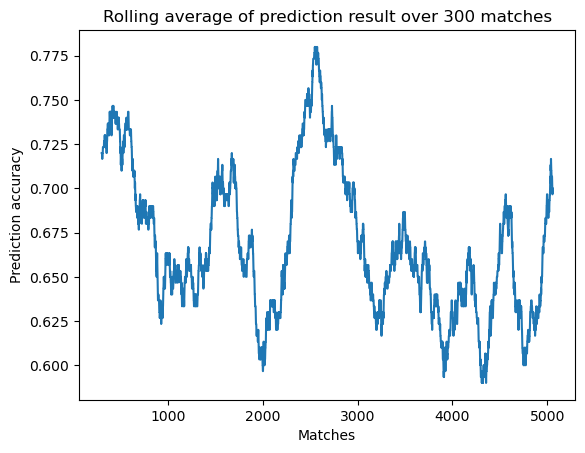

In [7]:
rolling_300 = correct_pred.rolling(window=300).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling_300)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 300 matches')
plt.show()

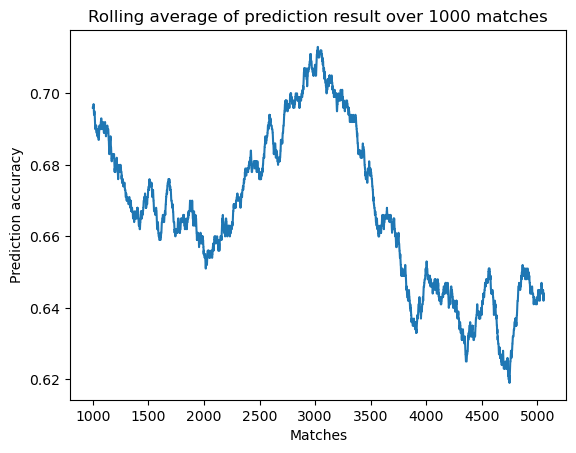

In [8]:
rolling_1k = correct_pred.rolling(window=1000).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling_1k)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 1000 matches')
plt.show()

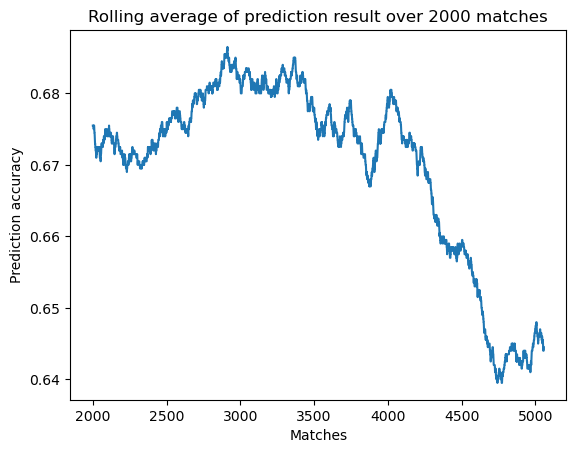

In [9]:
rolling_2k = correct_pred.rolling(window=2000).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling_2k)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 2000 matches')
plt.show()

From the two graphs, we see that the performance of prediction by our elo rating system drops significantly on the last 1000-2000 matches. We will try to investigate the reason below.

### Plot some stats of players

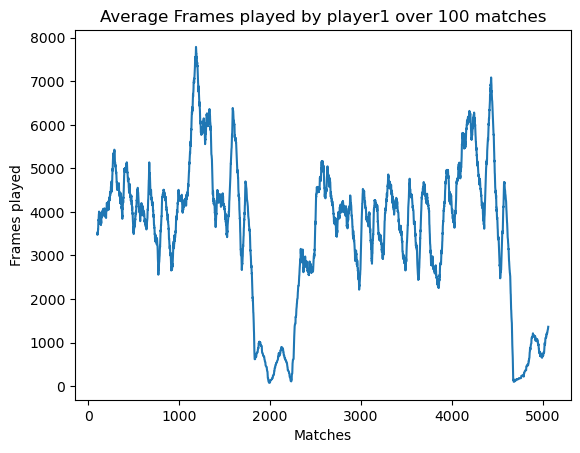

In [10]:
rolling1 = data['p1_frames_played'].rolling(window=100).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling1)
plt.xlabel('Matches')
plt.ylabel('Frames played')
plt.title('Average Frames played by player1 over 100 matches')
plt.show()

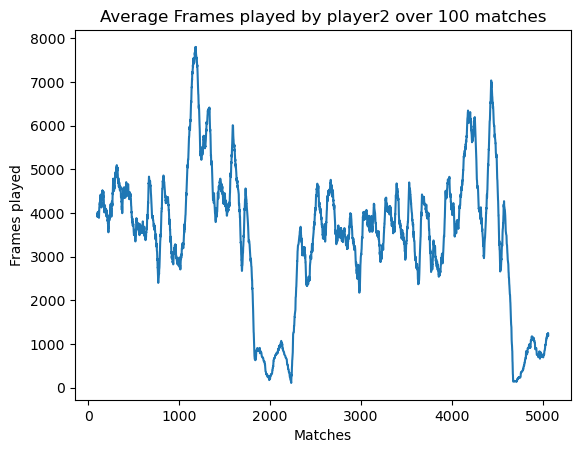

In [11]:
rolling2 = data['p2_frames_played'].rolling(window=100).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling2)
plt.xlabel('Matches')
plt.ylabel('Frames played')
plt.title('Average Frames played by player2 over 100 matches')
plt.show()

Two graphs indicate that the average number of frames played by players is significantly lower near 2000 and 5000. One reason for this trend can be that there are lots of matches that are not at the highest level are recorded and the players are not as experienced as the top players and don't have much professional matches record. For example, Pubo pointed out that Q school is a series of tournaments among amateurs happening in the early seaon every year which serves as qualification school for world snooker tour. These tournaments are among amateur players but still marked as professional level by our data source cuetracker.net.  

Let's us drop the these matches and see what can happen.

In [12]:
#Manually drop Q school matches. 

#We obtain the tournament id of Q school tournament from our data source cuetracker.net.
Q_school_tournament_ids = [6802, 6803, 6785, 6786,
                           6140, 6180, 6142, 6183]

for id in Q_school_tournament_ids: 
    matches_indices = data[data['tournament_id'] == id].index
    print(f'Deleting {len(data[data['tournament_id'] == id])} rows.')
    data.drop(matches_indices, axis = 0, inplace = True)

data.reset_index(inplace = True, drop = True)


Deleting 163 rows.
Deleting 159 rows.
Deleting 83 rows.
Deleting 81 rows.
Deleting 160 rows.
Deleting 153 rows.
Deleting 95 rows.
Deleting 93 rows.


In [13]:
data

,player1,player2,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,...,p1_frames_won_3_years,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,score1,score2,match_result,win_percentage,tournament_id
0,Cao Yupeng,Jiang Jun,9,1411,1044,0.918016,0.714532,341,179,2302,...,242,32,17,32,17,5,0,0.0,1.000000,5808
1,Siripaporn Nuanthakhamjan,Zhou Yuelong,9,965,1384,0.056881,0.259705,3,0,23,...,4,245,118,808,430,2,5,1.0,0.285714,5808
2,Wu Yize,Allan Taylor,9,1342,1237,0.656987,0.565251,78,37,552,...,215,101,49,336,147,5,3,0.0,0.625000,5808
3,Ben Woollaston,Oliver Brown,9,1412,1146,0.845318,0.660383,803,454,5053,...,282,91,35,235,97,5,2,0.0,0.714286,5808
4,Andres Petrov,Mark Williams,9,1045,1611,0.017765,0.195447,51,18,304,...,61,281,170,1112,649,2,5,1.0,0.285714,5808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4066,Luca Brecel,Judd Trump,25,1459,1639,0.128899,0.389361,673,392,4518,...,382,235,141,1554,970,8,13,1.0,0.380952,6743
4067,Ronnie O'Sullivan,Si Jiahui,25,1534,1409,0.784511,0.577495,1551,1178,13371,...,491,126,56,940,508,13,9,0.0,0.590909,6743
4068,Ronnie O'Sullivan,Zhao Xintong,33,1534,1504,0.585909,0.518741,1551,1178,13371,...,491,0,0,58,39,7,17,1.0,0.291667,6743
4069,Judd Trump,Mark Williams,33,1639,1497,0.847260,0.587830,1530,1103,10578,...,970,72,29,879,499,14,17,1.0,0.451613,6743


Run the rolling average of correct prediction again. 

In [14]:
new_prediction = data['player1_elo'] < data['player2_elo']
new_correct_pred = (new_prediction == data['match_result'])

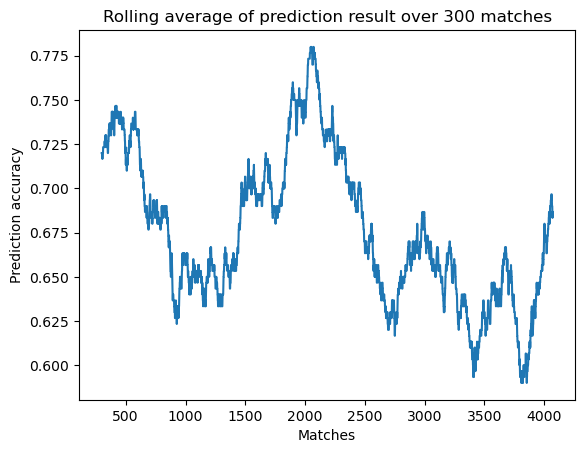

In [15]:
rolling2_300 = new_correct_pred.rolling(window=300).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling2_300)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 300 matches')
plt.show()

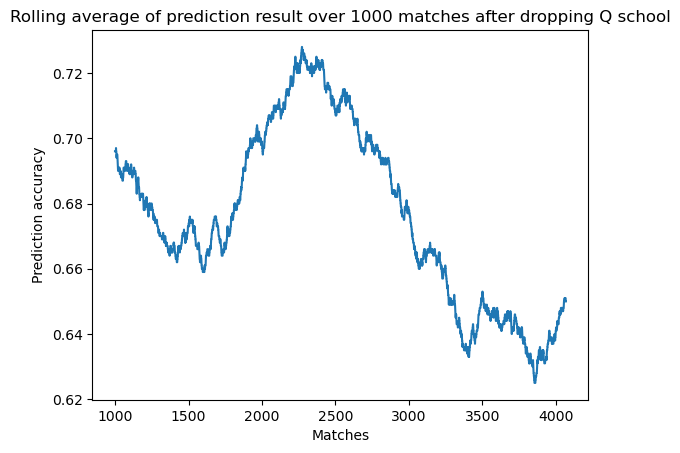

In [16]:
rolling2_1k = new_correct_pred.rolling(window=1000).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling2_1k)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 1000 matches after dropping Q school')
plt.show()

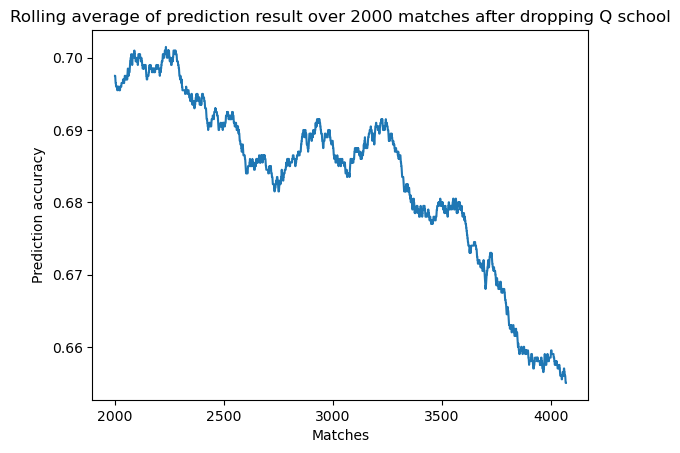

In [17]:
rolling2_2k = new_correct_pred.rolling(window=2000).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling2_2k)
plt.xlabel('Matches')
plt.ylabel('Prediction accuracy')
plt.title('Rolling average of prediction result over 2000 matches after dropping Q school')
plt.show()

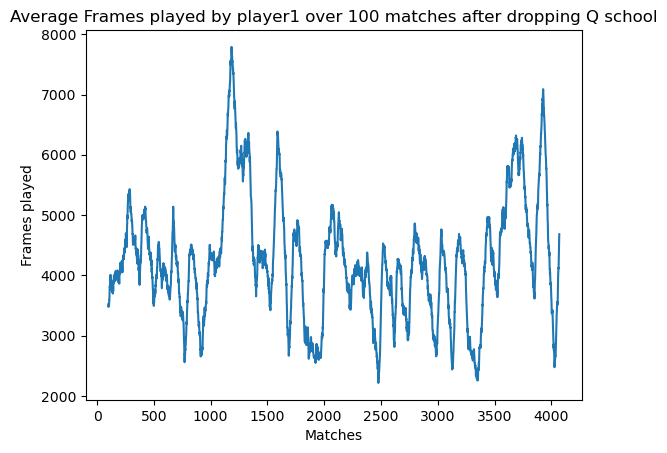

In [18]:
rolling2_1 = data['p1_frames_played'].rolling(window=100).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling2_1)
plt.xlabel('Matches')
plt.ylabel('Frames played')
plt.title('Average Frames played by player1 over 100 matches after dropping Q school')
plt.show()

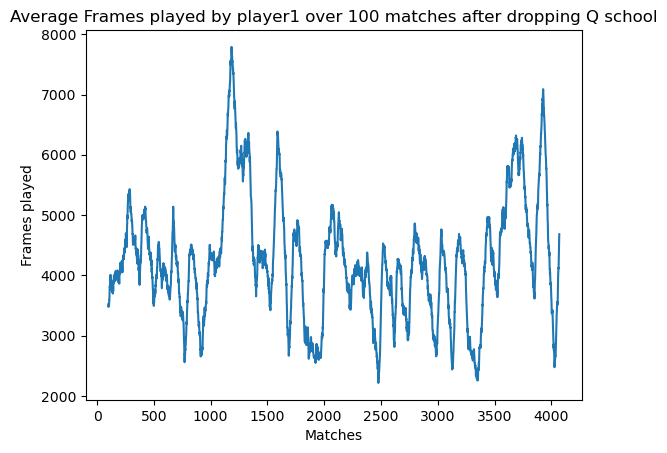

In [19]:
rolling2_2 = data['p1_frames_played'].rolling(window=100).mean()
plt.Figure(figsize = (16, 5))
plt.plot(rolling2_2)
plt.xlabel('Matches')
plt.ylabel('Frames played')
plt.title('Average Frames played by player1 over 100 matches after dropping Q school')
plt.show()

We see that after dropping the Q school matches, lots of matches with low average frames played were exluded. However, the average prediction accuracy is still low in the last 1000-2000 matches. 

***

## 2. Plot and interpret distributions of players' stats

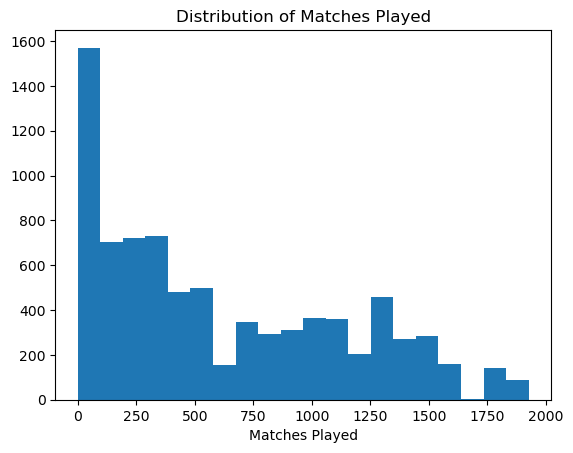

In [20]:
matches_played = pd.concat([data['p1_matches_played'], data['p1_matches_played']], axis = 0)
plt.hist(matches_played.values, bins = 20)
plt.xlabel('Matches Played')
plt.title('Distribution of Matches Played')
plt.show()

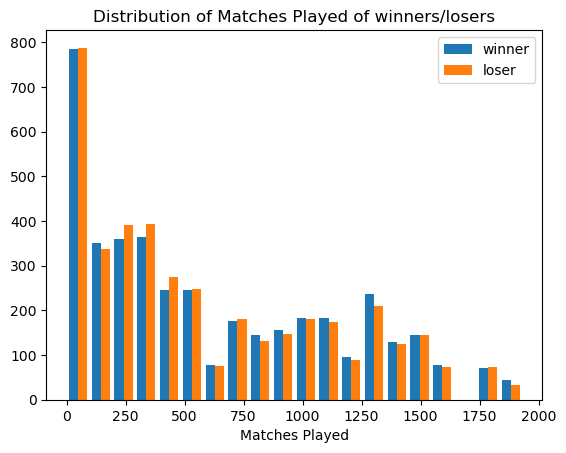

In [21]:
matches_played = pd.concat([data['p1_matches_played'], data['p2_matches_played']], axis = 1)
plt.hist(matches_played.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Matches Played')
plt.title('Distribution of Matches Played of winners/losers')
plt.legend()
plt.show()

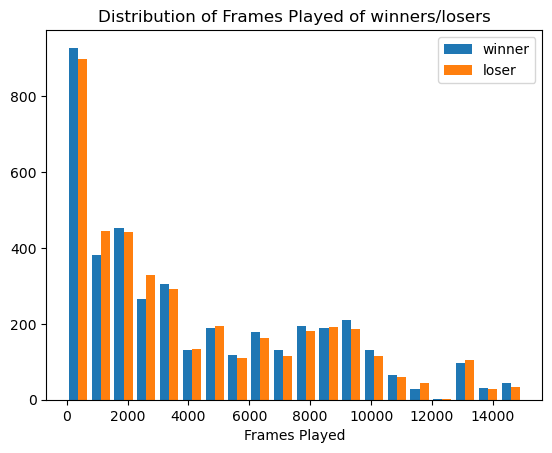

In [22]:
frames_played = pd.concat([data['p1_frames_played'], data['p2_frames_played']], axis = 1)
plt.hist(frames_played.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Frames Played')
plt.title('Distribution of Frames Played of winners/losers')
plt.legend()
plt.show()

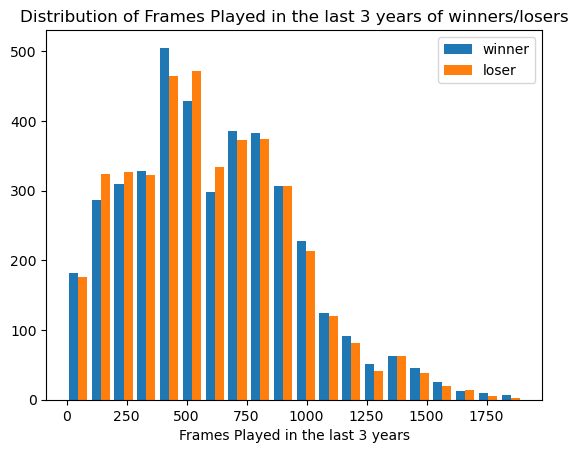

In [23]:
frames_played_3_years = pd.concat([data['p1_frames_played_3_years'], data['p2_frames_played_3_years']], axis = 1)
plt.hist(frames_played_3_years.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Frames Played in the last 3 years')
plt.title('Distribution of Frames Played in the last 3 years of winners/losers')
plt.legend()
plt.show()

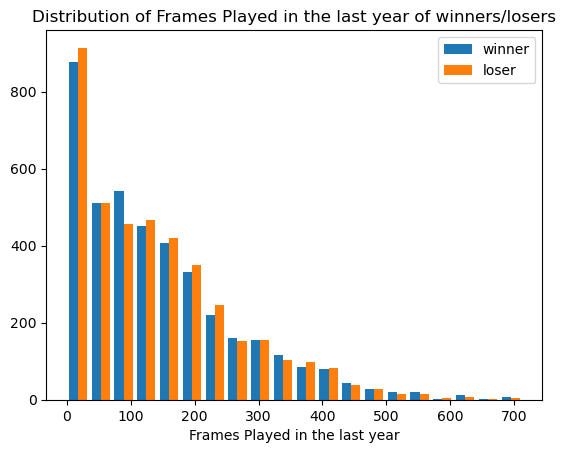

In [24]:
frames_played_1_year = pd.concat([data['p1_frames_played_1_year'], data['p2_frames_played_1_year']], axis = 1)
plt.hist(frames_played_1_year.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Frames Played in the last year')
plt.title('Distribution of Frames Played in the last year of winners/losers')
plt.legend()
plt.show()

We can see that there are lots of players with low or even zero matches and frames played. For these players, their matches are going to be very hard to predict because they haven't played enough game to establish their elo rating. Also, in the last four hisotgrams, the left most orange bar is obviously taller than the blue bar, indicating that the professional players who don't have much matches record tend to be the loser.

***

## 3. Plot and interpret the distribution of elo ratings.

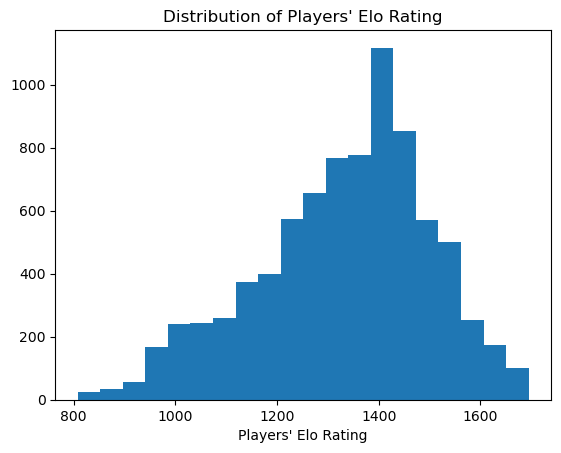

In [25]:
elo = pd.concat([data['player1_elo'], data['player2_elo']], axis = 0)
plt.hist(elo.values, bins = 20)
plt.xlabel('Players\' Elo Rating')
plt.title('Distribution of Players\' Elo Rating')
plt.show()


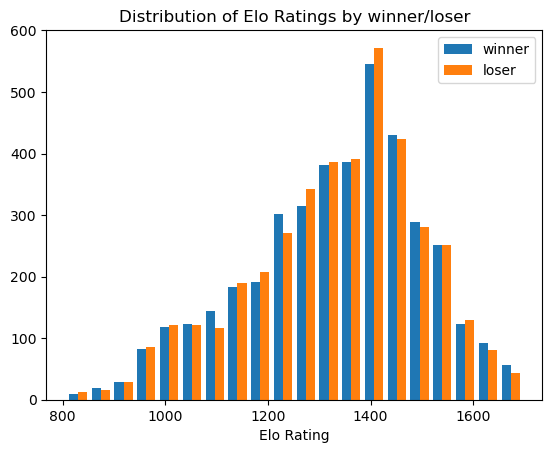

In [26]:
elo2 = pd.concat([data['player1_elo'], data['player2_elo']], axis = 1)
plt.hist(elo2.values, bins = 20, label = ['winner', 'loser'])
plt.xlabel('Elo Rating')
plt.title('Distribution of Elo Ratings by winner/loser')
plt.legend()
plt.show()

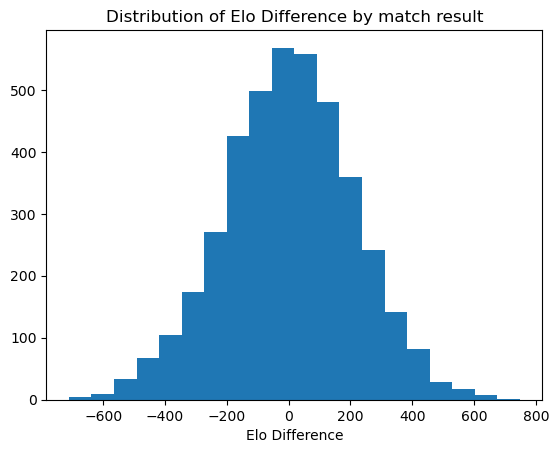

In [27]:
#Matches elo difference by result. Notice that in this data frame, player1 is always the winner. 
elo_diff = data['player1_elo'] - data['player2_elo']
plt.hist(elo_diff, bins = 20,)
plt.xlabel('Elo Difference')
plt.title('Distribution of Elo Difference by match result')
plt.show()


In [28]:
elo_diff.describe()

count    4071.000000
mean        0.912552
std       210.666298
min      -711.000000
25%      -139.000000
50%         4.000000
75%       144.000000
max       748.000000
dtype: float64

According to the histogram 'Distribution of Elo Difference by match result', the slight asymmetry betwen -200 and 200 indicates that our elo rating system is likely to predict the match result with accuracy nontrivially higher than 50%.

***

## 4. Explore the correlations between the columns

In this section, we will use modified version of the above data, where player1 and player2 are swapped for half of the matches, so that player1 will not always be the winner.

In [29]:
#Add more features: matches_win_rate, frames_win_rate
data['p1_frames_win_rate'] = data['p1_frames_won']/ data['p1_frames_played']
data['p2_frames_win_rate'] = data['p2_frames_won']/ data['p2_frames_played']

data['p1_matches_win_rate'] = data['p1_matches_won']/ data['p1_matches_played']
data['p2_matches_win_rate'] = data['p2_matches_won']/ data['p2_matches_played']

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4071 entries, 0 to 4070
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player1                   4071 non-null   object 
 1   player2                   4071 non-null   object 
 2   best_of                   4071 non-null   int64  
 3   player1_elo               4071 non-null   int64  
 4   player2_elo               4071 non-null   int64  
 5   elo_match_win_rate        4071 non-null   float64
 6   elo_frame_win_rate        4071 non-null   float64
 7   p1_matches_played         4071 non-null   int64  
 8   p1_matches_won            4071 non-null   int64  
 9   p1_frames_played          4071 non-null   int64  
 10  p1_frames_won             4071 non-null   int64  
 11  p2_matches_played         4071 non-null   int64  
 12  p2_matches_won            4071 non-null   int64  
 13  p2_frames_played          4071 non-null   int64  
 14  p2_frame

In [31]:
#Fill the missing value by 0.5
data.fillna(0.5, inplace =True)


In [32]:
data.describe()

,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,p1_frames_won,p2_matches_played,...,p2_frames_won_3_years,score1,score2,match_result,win_percentage,tournament_id,p1_frames_win_rate,p2_frames_win_rate,p1_matches_win_rate,p2_matches_win_rate
count,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,...,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000
mean,8.448047,1332.356423,1331.443871,0.503523,0.500705,616.138541,369.122574,4246.775731,2323.582903,598.939327,...,320.053795,3.442152,3.430361,0.502334,0.495247,6161.804225,0.508082,0.506861,0.523328,0.521050
std,4.316780,170.251987,168.746479,0.247462,0.123626,519.757630,351.212651,3830.437878,2220.562090,512.427998,...,204.929107,2.433192,2.406380,0.500056,0.289950,310.554528,0.067834,0.068097,0.124518,0.122371
min,1.000000,816.000000,808.000000,0.005286,0.144612,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,5203.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1227.500000,1229.500000,0.308124,0.413989,156.000000,70.000000,992.000000,468.500000,162.000000,...,163.000000,2.000000,2.000000,0.000000,0.285714,5950.000000,0.484291,0.484937,0.465398,0.466192
50%,7.000000,1356.000000,1357.000000,0.504614,0.502500,462.000000,236.000000,3011.000000,1523.000000,429.000000,...,290.000000,3.000000,3.000000,1.000000,0.500000,6217.000000,0.518126,0.516507,0.537791,0.533333
75%,11.000000,1453.000000,1447.000000,0.699552,0.589040,1033.000000,640.500000,7328.000000,3999.000000,1004.500000,...,444.500000,5.000000,5.000000,1.000000,0.714286,6400.000000,0.544335,0.543541,0.593272,0.590805
max,35.000000,1695.000000,1695.000000,0.998568,0.866458,1927.000000,1358.000000,14909.000000,8786.000000,1930.000000,...,1132.000000,14.000000,18.000000,1.000000,1.000000,6743.000000,0.800000,0.692308,1.000000,0.818182


<Axes: >

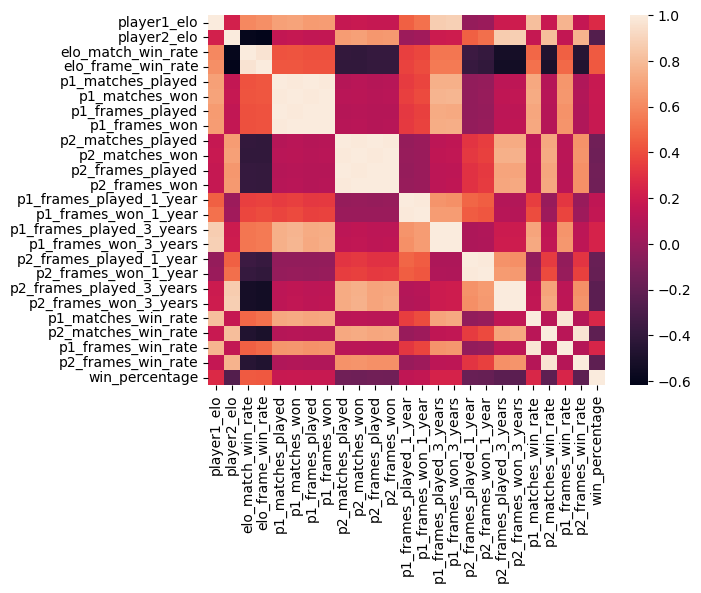

In [33]:
#We investigate the correlation among the following columns
columns = ['player1_elo', 'player2_elo',
       'elo_match_win_rate', 'elo_frame_win_rate', 'p1_matches_played',
       'p1_matches_won', 'p1_frames_played', 'p1_frames_won',
       'p2_matches_played', 'p2_matches_won', 'p2_frames_played',
       'p2_frames_won', 'p1_frames_played_1_year', 'p1_frames_won_1_year',
       'p1_frames_played_3_years', 'p1_frames_won_3_years',
       'p2_frames_played_1_year', 'p2_frames_won_1_year',
       'p2_frames_played_3_years', 'p2_frames_won_3_years', 
       'p1_matches_win_rate', 'p2_matches_win_rate',
       'p1_frames_win_rate', 'p2_frames_win_rate',
       'win_percentage']

corr = data[columns].corr()
sns.heatmap(corr)

In [34]:
#Print the features ranked by correlation with #Print the features ranked by correlation with win_percentage.
print(abs(corr["win_percentage"]).sort_values(ascending=False))
print(abs(corr["win_percentage"]).sort_values(ascending=False))

win_percentage              1.000000
elo_match_win_rate          0.441403
elo_frame_win_rate          0.432224
player1_elo                 0.271920
player2_elo                 0.266023
p1_matches_win_rate         0.256191
p1_frames_win_rate          0.251137
p1_frames_won_3_years       0.239228
p1_frames_played_3_years    0.235976
p2_frames_won_3_years       0.233636
p2_frames_played_3_years    0.232315
p2_matches_win_rate         0.222872
p2_frames_win_rate          0.219986
p2_frames_won_1_year        0.191301
p1_matches_won              0.185142
p2_frames_played_1_year     0.181762
p1_matches_played           0.178391
p1_frames_won               0.178282
p1_frames_played            0.174818
p2_matches_won              0.158794
p1_frames_won_1_year        0.155757
p2_matches_played           0.155100
p2_frames_won               0.149994
p2_frames_played            0.147700
p1_frames_played_1_year     0.141518
Name: win_percentage, dtype: float64
win_percentage              1.000000
e

We see that within the features, several players stats have high correlation with themselves.   

Also, players' elo rating have high correlation with their number of matches played in the recent three years.

Finally, the win rates predicted by our elo rating system have reached 0.42 correlation. This is promising. 

***

## 5. Principal Component Analysis

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [36]:
# Exclude the names and matches result from the analysis
X = data.drop(['player1', 'player2', 'match_result', 'win_percentage', 'score1', 'score2'], axis = 1)

In [37]:
X.describe()

,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,p1_frames_won,p2_matches_played,...,p1_frames_won_3_years,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,tournament_id,p1_frames_win_rate,p2_frames_win_rate,p1_matches_win_rate,p2_matches_win_rate
count,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,...,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000
mean,8.448047,1332.356423,1331.443871,0.503523,0.500705,616.138541,369.122574,4246.775731,2323.582903,598.939327,...,327.771801,143.487841,75.551953,598.970032,320.053795,6161.804225,0.508082,0.506861,0.523328,0.521050
std,4.316780,170.251987,168.746479,0.247462,0.123626,519.757630,351.212651,3830.437878,2220.562090,512.427998,...,211.722368,121.310596,69.533056,341.689762,204.929107,310.554528,0.067834,0.068097,0.124518,0.122371
min,1.000000,816.000000,808.000000,0.005286,0.144612,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,5203.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1227.500000,1229.500000,0.308124,0.413989,156.000000,70.000000,992.000000,468.500000,162.000000,...,167.000000,42.000000,20.000000,348.000000,163.000000,5950.000000,0.484291,0.484937,0.465398,0.466192
50%,7.000000,1356.000000,1357.000000,0.504614,0.502500,462.000000,236.000000,3011.000000,1523.000000,429.000000,...,298.000000,118.000000,58.000000,557.000000,290.000000,6217.000000,0.518126,0.516507,0.537791,0.533333
75%,11.000000,1453.000000,1447.000000,0.699552,0.589040,1033.000000,640.500000,7328.000000,3999.000000,1004.500000,...,454.500000,208.000000,109.000000,818.000000,444.500000,6400.000000,0.544335,0.543541,0.593272,0.590805
max,35.000000,1695.000000,1695.000000,0.998568,0.866458,1927.000000,1358.000000,14909.000000,8786.000000,1930.000000,...,1166.000000,712.000000,419.000000,1844.000000,1132.000000,6743.000000,0.800000,0.692308,1.000000,0.818182


In [38]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components=25)
pca.fit(X)
print("Explained variance:", pca.explained_variance_)

Explained variance: [9.08789407e+00 8.07173743e+00 2.62594875e+00 1.39007693e+00
 1.12987058e+00 9.58299042e-01 8.07644403e-01 7.67931784e-01
 4.64113320e-01 3.43386108e-01 1.25879048e-01 9.36182500e-02
 4.13142528e-02 2.57177785e-02 2.30617822e-02 1.34409509e-02
 1.32145671e-02 6.85599980e-03 6.29742067e-03 3.87741259e-03
 3.09996070e-03 1.26719023e-03 1.15215614e-03 6.24480371e-04
 3.43474543e-05]


In [39]:
data.shape

(4071, 32)

In [40]:
data.to_csv('match_data_after_explorations.csv', index = False)